# Apriori Software

## Librerias

In [1]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import matplotlib.pyplot as plt
import networkx as nx

## Clases

In [2]:
from src.utils import path

# Lectura de DF procesado

In [3]:
directorio_proyecto = path.obtener_ruta_local()
datos = pd.read_csv(directorio_proyecto+'\\data\\processed\\Software.csv',delimiter = ',',decimal = ".", encoding='utf-8')
datos.head()

,Row ID,Order ID,Order Date,Date Key,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit,Reglas
0,1,EMEA-2022-152156,11/9/2022,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,Marketing Suite,16GRM07R1K,261.9600,2,0.00,41.9136,"EMEA,UKIR,Energy,SMB,Marketing Suite"
1,2,EMEA-2022-152156,11/9/2022,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,FinanceHub,QLIW57KZUV,731.9400,3,0.00,219.5820,"EMEA,UKIR,Energy,SMB,FinanceHub"
2,3,AMER-2022-138688,6/13/2022,20220613,Deirdre Bailey,United States,New York City,AMER,NAMER,Phillips 66,1056,Energy,Strategic,FinanceHub,JI6BVL70HQ,14.6200,2,0.00,6.8714,"AMER,NAMER,Energy,Strategic,FinanceHub"
3,4,EMEA-2021-108966,10/11/2021,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,ContactMatcher,DE9GJKGD44,957.5775,5,0.45,-383.0310,"EMEA,EU-WEST,Energy,SMB,ContactMatcher"
4,5,EMEA-2021-108966,10/11/2021,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,Marketing Suite - Gold,OIF7NY23WD,22.3680,2,0.20,2.5164,"EMEA,EU-WEST,Energy,SMB,Marketing Suite - Gold"


In [4]:
df_reglas_software = datos[["Reglas"]]
df_reglas_software.head()

,Reglas
0,"EMEA,UKIR,Energy,SMB,Marketing Suite"
1,"EMEA,UKIR,Energy,SMB,FinanceHub"
2,"AMER,NAMER,Energy,Strategic,FinanceHub"
3,"EMEA,EU-WEST,Energy,SMB,ContactMatcher"
4,"EMEA,EU-WEST,Energy,SMB,Marketing Suite - Gold"


In [5]:
df_reglas_software.shape

(9994, 1)

In [6]:
print(df_reglas_software.columns.tolist())

['Reglas']


In [7]:
data = list(df_reglas_software["Reglas"].apply(lambda x:x.split(",") ))
data

[['EMEA', 'UKIR', 'Energy', 'SMB', 'Marketing Suite'],
 ['EMEA', 'UKIR', 'Energy', 'SMB', 'FinanceHub'],
 ['AMER', 'NAMER', 'Energy', 'Strategic', 'FinanceHub'],
 ['EMEA', 'EU-WEST', 'Energy', 'SMB', 'ContactMatcher'],
 ['EMEA', 'EU-WEST', 'Energy', 'SMB', 'Marketing Suite - Gold'],
 ['AMER', 'NAMER', 'Finance', 'SMB', 'SaaS Connector Pack'],
 ['AMER', 'NAMER', 'Finance', 'SMB', 'ChatBot Plugin'],
 ['AMER', 'NAMER', 'Finance', 'SMB', 'Site Analytics'],
 ['AMER', 'NAMER', 'Finance', 'SMB', 'ContactMatcher'],
 ['AMER', 'NAMER', 'Finance', 'SMB', 'OneView'],
 ['AMER', 'NAMER', 'Finance', 'SMB', 'ContactMatcher'],
 ['AMER', 'NAMER', 'Finance', 'SMB', 'Site Analytics'],
 ['EMEA', 'NOR', 'Energy', 'SMB', 'Support'],
 ['AMER', 'NAMER', 'Tech', 'SMB', 'ContactMatcher'],
 ['APJ', 'JAPN', 'Healthcare', 'Enterprise', 'OneView'],
 ['APJ', 'JAPN', 'Healthcare', 'Enterprise', 'ContactMatcher'],
 ['EMEA', 'EU', 'Manufacturing', 'SMB', 'Marketing Suite - Gold'],
 ['EMEA', 'MEA', 'Retail', 'SMB', 'Mark

In [8]:
a = TransactionEncoder()
a_data = a.fit(data).transform(data)
df = pd.DataFrame(a_data,columns=a.columns_)
df = df.replace(False,0)
df

,AMER,ANZ,APAC,APJ,Alchemy,Big Ol Database,ChatBot Plugin,Communications,Consumer Products,ContactMatcher,...,SMB,SaaS Connector Pack,SaaS Connector Pack - Gold,Site Analytics,Storage,Strategic,Support,Tech,Transportation,UKIR
0,0,0,0,0,0,0,0,0,0,0,...,True,0,0,0,0,0,0,0,0,True
1,0,0,0,0,0,0,0,0,0,0,...,True,0,0,0,0,0,0,0,0,True
2,True,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,True,0,0,0,0
3,0,0,0,0,0,0,0,0,0,True,...,True,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,True,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,0,0,0,0,0,0,0,0,0,0,...,True,True,0,0,0,0,0,0,0,0
9990,True,0,0,0,0,0,0,0,0,0,...,True,True,0,0,0,0,0,0,0,0
9991,True,0,0,0,0,0,0,0,0,0,...,True,0,0,True,0,0,0,0,0,0
9992,True,0,0,0,0,0,0,0,0,0,...,True,0,0,0,0,0,True,0,0,0


In [9]:
df.shape

(9994, 42)

In [10]:
#establezca un valor umbral para el valor de soporte y calcule el valor de soporte.
df = apriori(df, min_support = 0.1, use_colnames = True, verbose = 1)
df

Processing 75 combinations | Sampling itemset size 32


C:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
0,0.36672,frozenset({AMER})
1,0.211127,frozenset({APJ})
2,0.102161,frozenset({Consumer Products})
3,0.184311,frozenset({ContactMatcher})
4,0.422153,frozenset({EMEA})
5,0.161497,frozenset({EU-WEST})
6,0.131679,frozenset({Energy})
7,0.178407,frozenset({Enterprise})
8,0.212828,frozenset({Finance})
9,0.104963,frozenset({Healthcare})


In [11]:
#Veamos nuestros valores de interpretación usando la función de regla asociativa.
df_ar = association_rules(df, metric = "confidence", min_threshold = 0.5)
df_ar

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({LATAM}),frozenset({AMER}),0.115870,0.366720,0.115870,1.000000,2.726876,1.0,0.073378,inf,0.716274,0.315962,1.000000,0.657981
1,frozenset({AMER}),frozenset({NAMER}),0.366720,0.250851,0.250851,0.684038,2.726876,1.0,0.158859,2.371013,1.000000,0.684038,0.578239,0.842019
2,frozenset({NAMER}),frozenset({AMER}),0.250851,0.366720,0.250851,1.000000,2.726876,1.0,0.158859,inf,0.845332,0.684038,1.000000,0.842019
3,frozenset({AMER}),frozenset({SMB}),0.366720,0.519412,0.191915,0.523329,1.007541,1.0,0.001436,1.008218,0.011819,0.276449,0.008151,0.446407
4,frozenset({APJ}),frozenset({SMB}),0.211127,0.519412,0.109366,0.518009,0.997300,1.0,-0.000296,0.997091,-0.003420,0.176063,-0.002918,0.364283
5,frozenset({EU-WEST}),frozenset({EMEA}),0.161497,0.422153,0.161497,1.000000,2.368808,1.0,0.093320,inf,0.689141,0.382555,1.000000,0.691278
6,frozenset({EMEA}),frozenset({SMB}),0.422153,0.519412,0.218131,0.516710,0.994799,1.0,-0.001140,0.994410,-0.008967,0.301521,-0.005621,0.468334
7,frozenset({UKIR}),frozenset({EMEA}),0.126776,0.422153,0.126776,1.000000,2.368808,1.0,0.073257,inf,0.661739,0.300308,1.000000,0.650154
8,frozenset({Finance}),frozenset({SMB}),0.212828,0.519412,0.117170,0.550541,1.059931,1.0,0.006625,1.069259,0.071830,0.190499,0.064773,0.388062
9,frozenset({NAMER}),frozenset({SMB}),0.250851,0.519412,0.132379,0.527722,1.016000,1.0,0.002085,1.017597,0.021022,0.207529,0.017293,0.391293


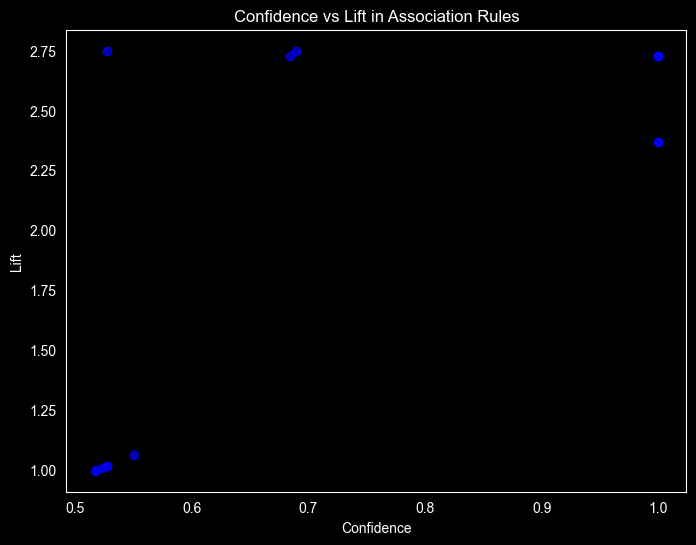

In [12]:
# Scatter plot of confidence vs lift
plt.figure(figsize=(8,6))
plt.scatter(df_ar['confidence'], df_ar['lift'], alpha=0.7, color='b')
plt.xlabel('Confidence')
plt.ylabel('Lift')
plt.title('Confidence vs Lift in Association Rules')
plt.grid()
plt.show()

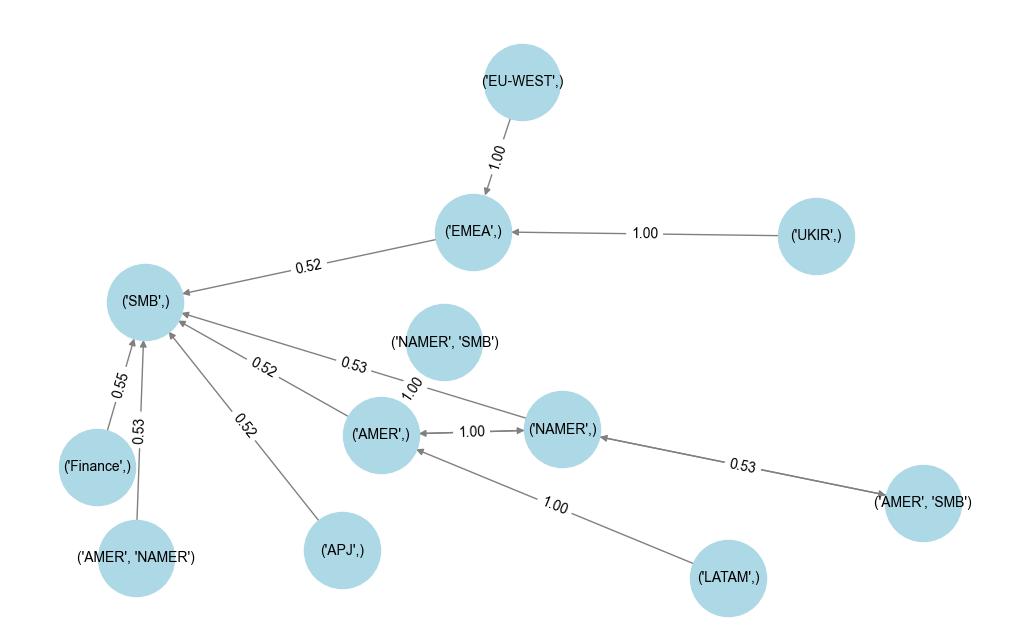

In [13]:
# Visualizing association rules as a network graph
G = nx.DiGraph()
for _, row in df_ar.iterrows():
    G.add_edge(tuple(row['antecedents']), tuple(row['consequents']), weight=row['confidence'])
plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=3000, font_size=10)
edge_labels = {(tuple(row['antecedents']), tuple(row['consequents'])): f"{row['confidence']:.2f}"
               for _, row in df_ar.iterrows()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Association Rules Network")
plt.show()